# Phase 04 Minimal Baseline Demo

Purpose: verify that the Phase 03 no-performance dataset can enter a leakage-aware modelling pipeline.

This notebook uses `subject_id` as the group variable and evaluates conventional ML baselines with `GroupKFold`.
The results are preliminary feasibility evidence, not final thesis results.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

ROOT = Path(r"E:/hdc-vr-pilot")
TEST_DIR = ROOT / "test"
sys.path.insert(0, str(TEST_DIR))

from hdc_demo_utils import load_phase03_dataset, get_feature_columns, evaluate_sklearn_models

RESULTS = TEST_DIR / "results"
FIGURES = TEST_DIR / "figures"
RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)


In [2]:
df = load_phase03_dataset()
feature_cols = get_feature_columns(df)
X = df[feature_cols]
y = df["target"].astype(int).to_numpy()
groups = df["subject_id"].astype(str).to_numpy()

print("Dataset shape:", df.shape)
print("Number of model features:", len(feature_cols))
print("Number of subjects:", pd.Series(groups).nunique())
display(df[["subject_id", "run_id", "difficulty_level", "target"]].head())
display(df["target"].value_counts().sort_index().rename("count").to_frame())


Dataset shape: (419, 1182)
Number of model features: 1176
Number of subjects: 35


,subject_id,run_id,difficulty_level,target
0,sub-cp003,run-001,1,0
1,sub-cp003,run-007,1,0
2,sub-cp003,run-012,1,0
3,sub-cp003,run-003,2,1
4,sub-cp003,run-008,2,1


,count
target,
0,104
1,106
2,104
3,105


In [3]:
models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ]),
    "Linear SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearSVC(class_weight="balanced", random_state=42, max_iter=5000)),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=120, class_weight="balanced", random_state=42, n_jobs=1)),
    ]),
}

fold_metrics, summary, confusion = evaluate_sklearn_models(X, y, groups, models, n_splits=5)
display(summary)
fold_metrics.to_csv(RESULTS / "phase04_minimal_baseline_fold_metrics.csv", index=False)
summary.to_csv(RESULTS / "phase04_minimal_baseline_summary.csv", index=False)


,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,fit_predict_seconds_mean,fit_predict_seconds_std
2,Random Forest,0.933247,0.049449,0.933723,0.048516,0.932800,0.049696,0.932755,0.049973,0.617131,0.011103
0,Linear SVM,0.739931,0.039286,0.739805,0.039204,0.742883,0.033672,0.742886,0.033635,1.580610,0.423582
1,Logistic Regression,0.730407,0.030113,0.730281,0.029843,0.732619,0.028280,0.732654,0.028340,0.121628,0.003349


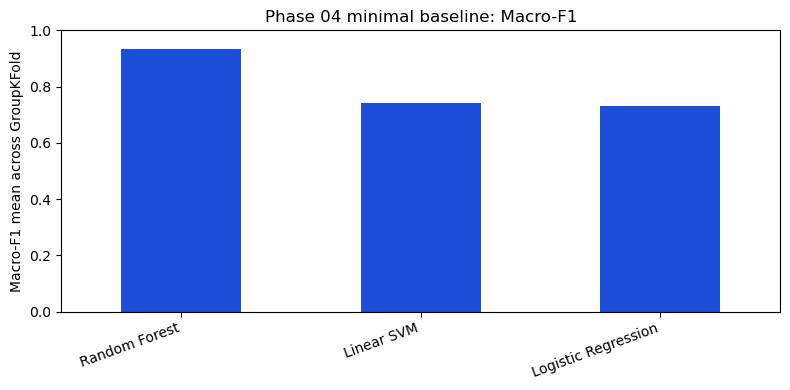

Best preliminary baseline by mean Macro-F1: Random Forest


,pred_0,pred_1,pred_2,pred_3
true_0,99,0,4,1
true_1,6,89,9,2
true_2,1,1,99,3
true_3,0,0,1,104


In [4]:
ax = summary.plot(x="model", y="macro_f1_mean", kind="bar", legend=False, figsize=(8, 4), color="#1d4ed8")
ax.set_title("Phase 04 minimal baseline: Macro-F1")
ax.set_xlabel("")
ax.set_ylabel("Macro-F1 mean across GroupKFold")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGURES / "phase04_minimal_baseline_macro_f1.png", dpi=160)
plt.show()

best_model = summary.iloc[0]["model"]
print("Best preliminary baseline by mean Macro-F1:", best_model)
pd.DataFrame(confusion[best_model], index=["true_0", "true_1", "true_2", "true_3"], columns=["pred_0", "pred_1", "pred_2", "pred_3"]).to_csv(RESULTS / "phase04_best_baseline_confusion_matrix.csv")
display(pd.DataFrame(confusion[best_model], index=["true_0", "true_1", "true_2", "true_3"], columns=["pred_0", "pred_1", "pred_2", "pred_3"]))


## Interpretation for P1 defense

This notebook demonstrates that the constructed Phase 03 dataset can be used in a subject-wise modelling pipeline.
The baseline results should be described as preliminary feasibility evidence before the formal HDC experiments.
